# Overall Summary

## Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import libraries.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.stats import linregress
import pingouin as pg

Build dataframe

In [59]:
df = pd.read_csv("data.csv", encoding="utf-8-sig")
df.head()

,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,crosswalk_used_ratio_mid_penalty,crosswalk_used_ratio_high_penalty,jaywalking_ratio_total,jaywalking_ratio_easy,jaywalking_ratio_hard,jaywalking_ratio_low_penalty,jaywalking_ratio_mid_penalty,jaywalking_ratio_high_penalty,DDT_mean_log_k,CRA_mean_alpha
0,100,29,2,16,77,30,25,22,96,45,...,0.176471,0.181818,0.289474,0.300000,0.282609,0.300000,0.264706,0.318182,-6.945853,0.851175
1,502,1001,2,12,79,31,25,23,104,51,...,0.037736,0.051852,0.270081,0.268987,0.270718,0.261993,0.286164,0.259259,-4.945853,0.751175
2,503,1901,1,1234,80,36,24,20,109,56,...,0.052023,0.041420,0.242483,0.234043,0.247328,0.253602,0.236994,0.236686,-2.945853,1.111751


Utils

In [26]:
def print_summary(data, name):
    print(f"{name}: mean = {data.mean():.2f}, std = {data.std():.2f} (min={data.min()} ~ max={data.max()})")

def plot_summary(plot, data, title, xlable=None, ylable=None, bins=10):
    plot.hist(data, bins=bins, edgecolor="black")
    if xlable is not None:
        plot.set_xlabel(xlable)
    else:
        plot.set_xlabel(title)
    if ylable is not None:
        plot.set_ylabel("Frequency")
    else:
        plot.set_ylabel(ylable)
    plot.set_title(title)

def scatter_plot_with_line_regression(plot, x, y, xlabel, ylabel, title):
    plot.scatter(x, y)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    plot.plot(line_x, line_y, color="red")

    plot.set_xlabel(xlabel)
    plot.set_ylabel(ylabel)
    plot.set_title(f"{title}\nr={r_value:.3f}")

## Survey

### Demographics

Age: mean = 977.00, std = 936.23 (min=29 ~ max=1901)
2 males & 1 females


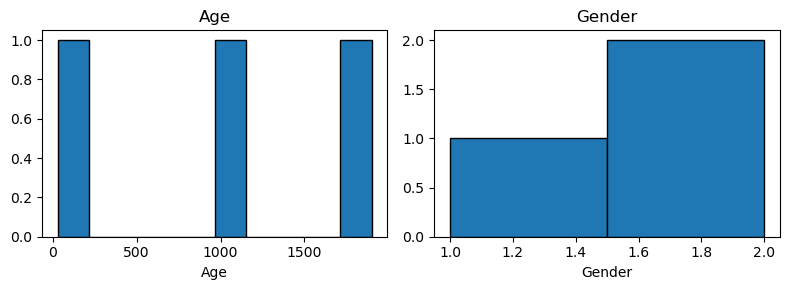

In [27]:
print_summary(df["age"], "Age")
print(f"{len(df[df['gender'] == 2])} males & {len(df[df['gender'] == 1])} females")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_summary(axes[0], df["age"], "Age")
plot_summary(axes[1], df["gender"], "Gender", bins=2)
plt.tight_layout()
plt.show()

### BIS

BIS: mean = 78.67, std = 1.53 (min=77 ~ max=80)
BIS_motor: mean = 32.33, std = 3.21 (min=30 ~ max=36)
BIS_nonplanning: mean = 24.67, std = 0.58 (min=24 ~ max=25)
BIS_attentional: mean = 21.67, std = 1.53 (min=20 ~ max=23)


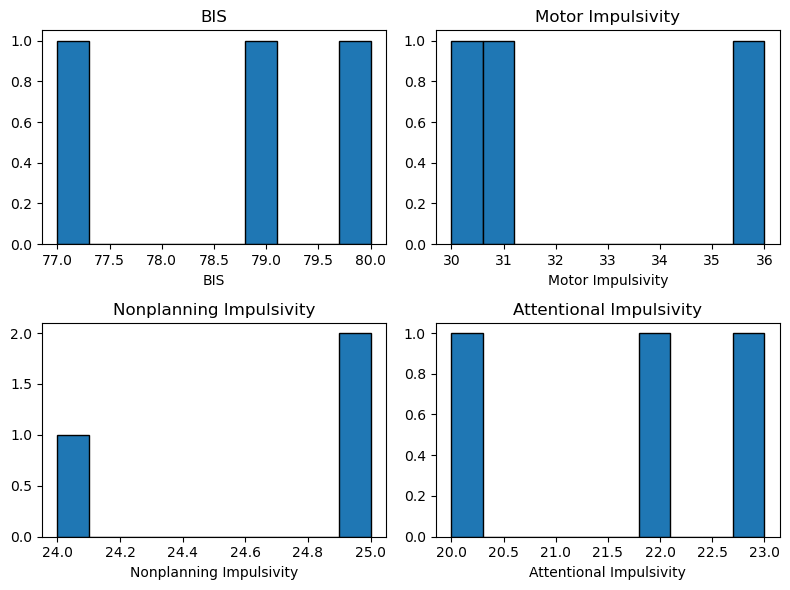

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i in range(4):
    col = ["BIS", "BIS_motor", "BIS_nonplanning", "BIS_attentional"][i]
    title = ["BIS", "Motor Impulsivity", "Nonplanning Impulsivity", "Attentional Impulsivity"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 2, i % 2], df[col], title)
plt.tight_layout()
plt.show()

### STAI

STAI: mean = 103.00, std = 6.56 (min=96 ~ max=109)
STAI_S: mean = 50.67, std = 5.51 (min=45 ~ max=56)
STAI_T: mean = 52.33, std = 1.15 (min=51 ~ max=53)


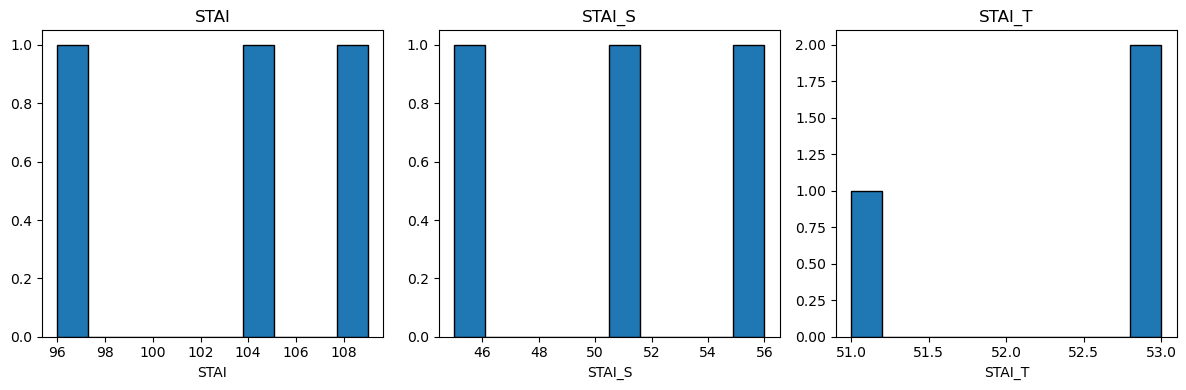

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["STAI", "STAI_S", "STAI_T"][i]
    print_summary(df[col], col)
    plot_summary(axes[i], df[col], col)
plt.tight_layout()
plt.show()

### DOSPERT

DOSPERT: mean = 106.33, std = 16.20 (min=96 ~ max=125)
DOSPERT_ETH: mean = 18.33, std = 5.51 (min=13 ~ max=24)
DOSPERT_FIN: mean = 22.67, std = 3.79 (min=20 ~ max=27)
DOSPERT_HEA: mean = 22.00, std = 4.36 (min=17 ~ max=25)
DOSPERT_REC: mean = 22.67, std = 3.21 (min=19 ~ max=25)
DOSPERT_SOC: mean = 20.67, std = 4.16 (min=16 ~ max=24)


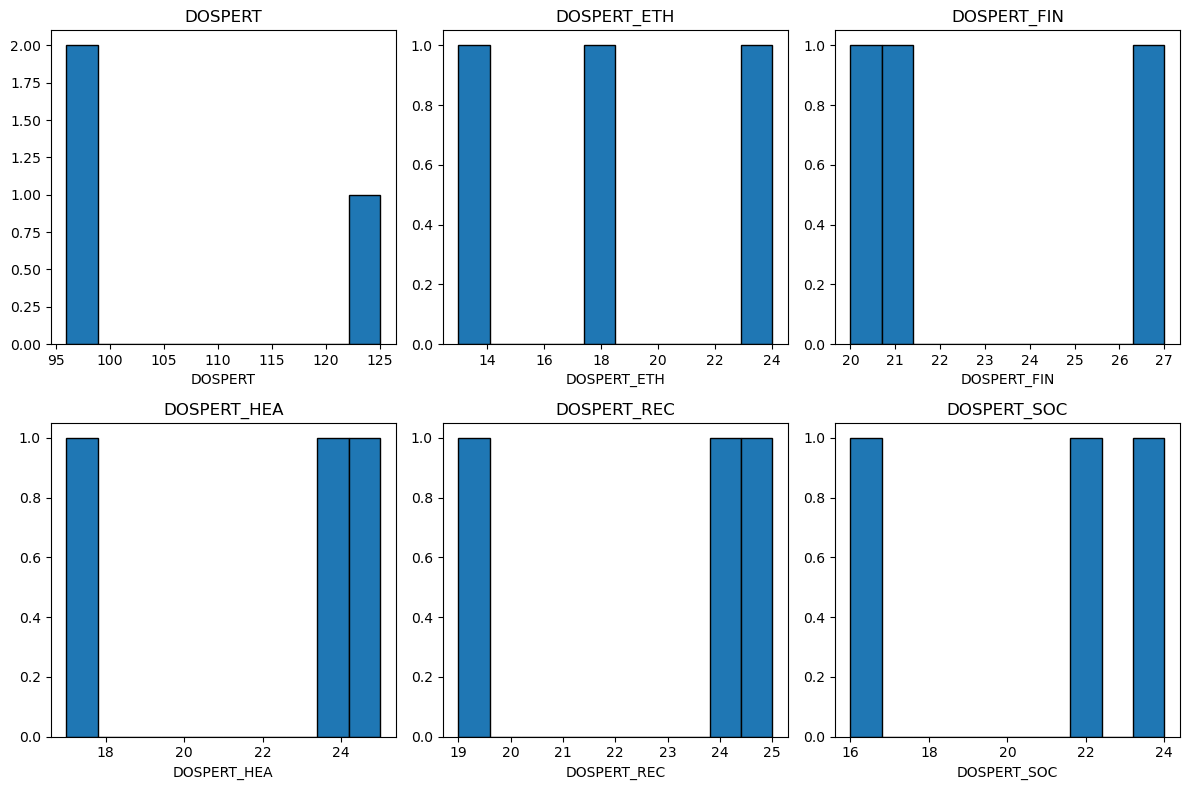

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = ["DOSPERT", "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"][i]
    title = ["DOSPERT", "Ethical Risk Taking", "Financial Risk Taking", "Health and Safety Risk Taking", "Recreational Risk Taking", "Social Risk Taking"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 3, i % 3], df[col], col)
plt.tight_layout()
plt.show()

### CES-D

CES-D: mean = 53.00, std = 0.00 (min=53 ~ max=53)


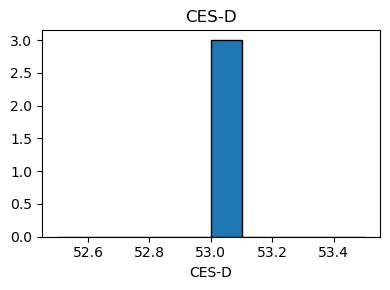

In [31]:
print_summary(df["CES_D"], "CES-D")
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
plot_summary(axes, df["CES_D"], "CES-D")
plt.tight_layout()
plt.show()

## Traditional Behavior Tasks

DDT - Discounting Rate (log k): mean = -4.95, std = 2.00 (min=-6.945852756500244 ~ max=-2.945852756500244)
CRA - Risk Preference (alpha): mean = 0.90, std = 0.19 (min=0.7511751294136046 ~ max=1.111751294136047)


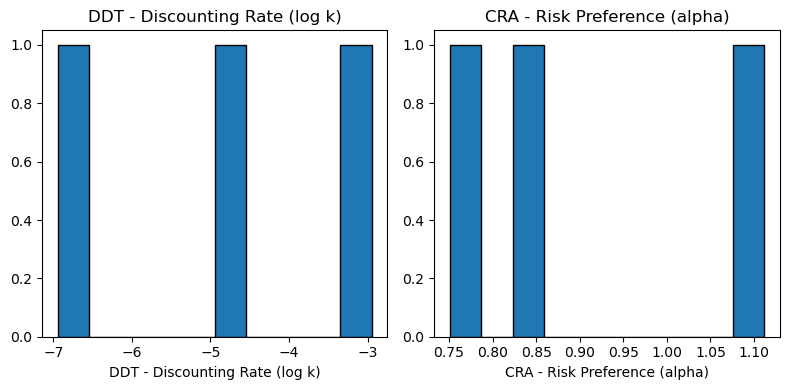

In [32]:
print_summary(df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
print_summary(df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_summary(axes[0], df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
plot_summary(axes[1], df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")
plt.tight_layout()
plt.show()

## Pedestrian Task

### Scores

Total Score: mean = 128900.00, std = 105869.48 (min=6800 ~ max=195150)
Best Score: mean = 1900.00, std = 435.89 (min=1400 ~ max=2200)
Mean Score: mean = 1350.28, std = 952.69 (min=251.85185185185185 ~ max=1951.5)
STD Score: mean = 362.24, std = 48.79 (min=306.20312463355685 ~ max=395.3246332529326)


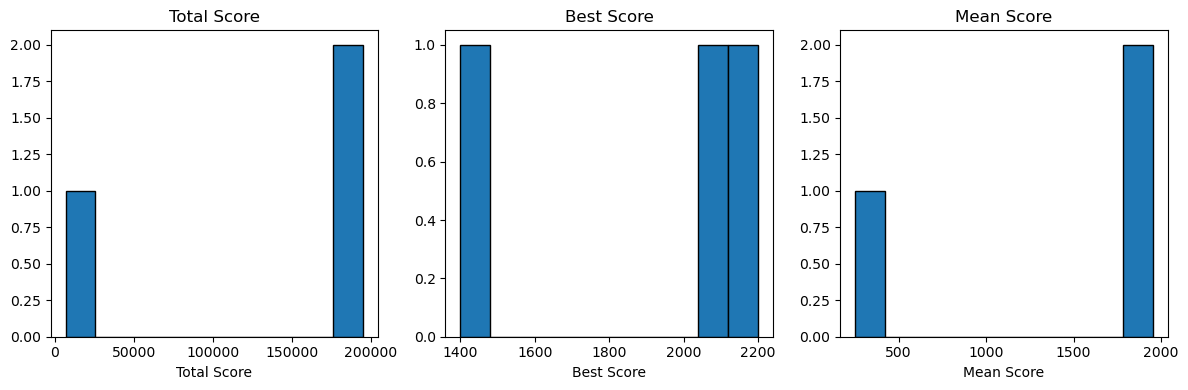

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["total_score_full", "best_score_full", "average_score_full"][i]
    title = ["Total Score", "Best Score", "Mean Score"][i]
    print_summary(df[col], title)
    plot_summary(axes[i], df[col], title)
print_summary(df['std_score_full'], "STD Score")
plt.tight_layout()
plt.show()

### Split-half Reliability

- ICC(3,1) reflects the degree of absolute agreement between two **fixed** raters, indicating how consistent the scores from Session 1 and Session 2 are for each participant
- Ssould be at least 0.5, but needs enough sample size (N)
- "The split-half reliability between the scores in the first half and the second half of the task assessed by the intraclass correlation coefficient (Koo & Li, 2016) was .72, which is acceptable." (Lee et al., 2014)

In [34]:
print_summary(df['total_score_session1'], "Total Score (Session 1")
print_summary(df['total_score_session2'], "Total Score (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['total_score_session1'].values, df['total_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc3 = icc_table.loc[icc_table["Type"] == "ICC3"]
print(f"ICC = {icc3['ICC'].values[0]:.2f}")
icc3

Total Score (Session 1: mean = 66850.00, std = 52404.08 (min=6350 ~ max=98100)
Total Score (Session 2): mean = 62050.00, std = 53512.24 (min=450 ~ max=97050)
ICC = -0.57


,Type,Description,ICC,F,df1,df2,pval,CI95%
2,ICC3,Single fixed raters,-0.569312,0.274444,2,2,0.784656,"[-0.99, 0.83]"


In [35]:
print_summary(df['average_score_session1'], "Score Mean (Session 1)")
print_summary(df['average_score_session2'], "Score Mean (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['average_score_session1'].values, df['average_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc3 = icc_table.loc[icc_table["Type"] == "ICC3"]
print(f"ICC = {icc3['ICC'].values[0]:.2f}")
icc3

Score Mean (Session 1): mean = 1376.08, std = 980.41 (min=244.23076923076923 ~ max=1962.0)
Score Mean (Session 2): mean = 1388.00, std = 816.66 (min=450 ~ max=1941)
ICC = -0.57


,Type,Description,ICC,F,df1,df2,pval,CI95%
2,ICC3,Single fixed raters,-0.57265,0.271739,2,2,0.786325,"[-0.99, 0.83]"


### Crosswalk Usage Ratios

In [36]:
col_types = ["total", "easy", "hard", "low_penalty", "mid_penalty", "high_penalty"]
xlables = ["Total", "Easy", "Hard", "Low Penalty", "Mid Penalty", "High Penalty"]

Total: mean = 655.33, std = 509.03 (min=76 ~ max=1031)
Easy: mean = 240.67, std = 184.89 (min=30 ~ max=376)
Hard: mean = 414.67, std = 324.15 (min=46 ~ max=655)
Low Penalty: mean = 212.67, std = 171.13 (min=20 ~ max=347)
Mid Penalty: mean = 232.67, std = 172.62 (min=34 ~ max=346)
High Penalty: mean = 210.00, std = 166.32 (min=22 ~ max=338)


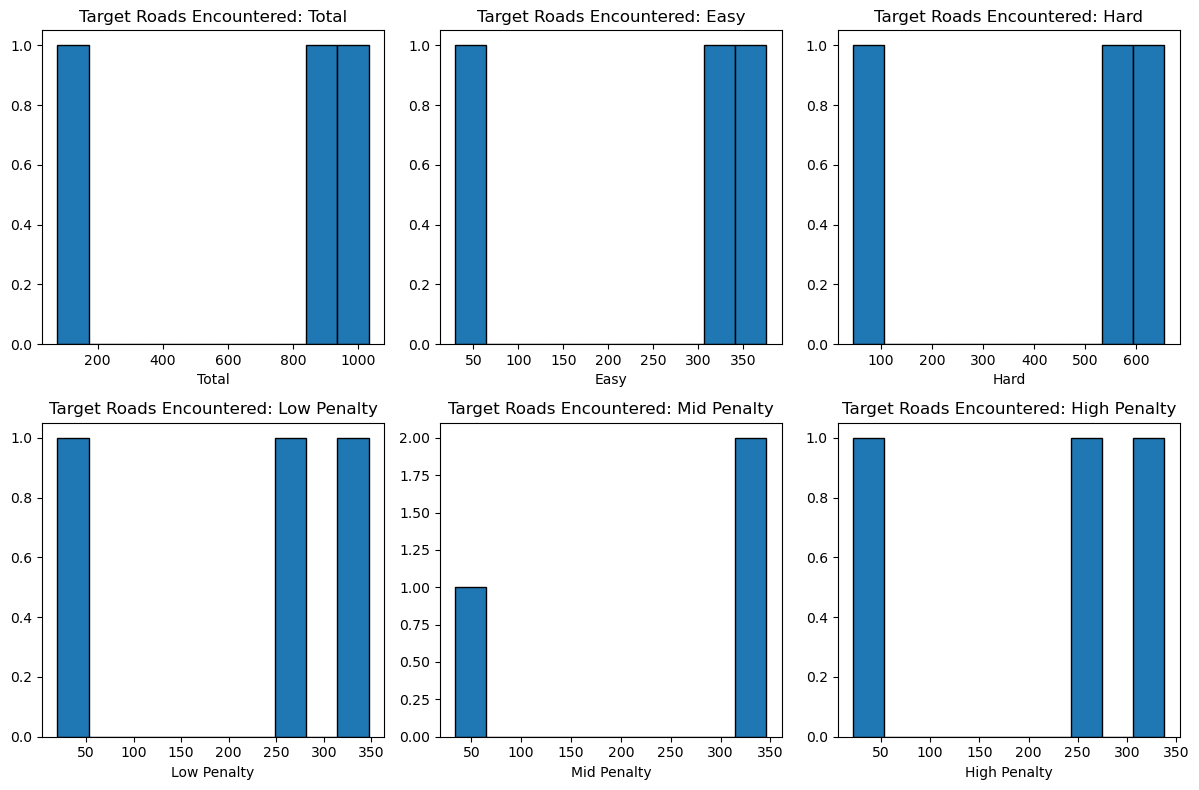

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = f"total_target_roads_{col_types[i]}"
    xlable = xlables[i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable=xlable, title=f"Target Roads Encountered: {xlable}")
plt.tight_layout()
plt.show()

Total: mean = 0.09, std = 0.08 (min=0.040737148399612 ~ max=0.1842105263157894)
Easy: mean = 0.08, std = 0.07 (min=0.0348101265822784 ~ max=0.1666666666666666)
Hard: mean = 0.09, std = 0.09 (min=0.0396946564885496 ~ max=0.1956521739130435)
Low Penalty: mean = 0.09, std = 0.09 (min=0.0345821325648415 ~ max=0.2)
Mid Penalty: mean = 0.09, std = 0.08 (min=0.0377358490566037 ~ max=0.1764705882352941)
High Penalty: mean = 0.09, std = 0.08 (min=0.0384615384615384 ~ max=0.1818181818181818)


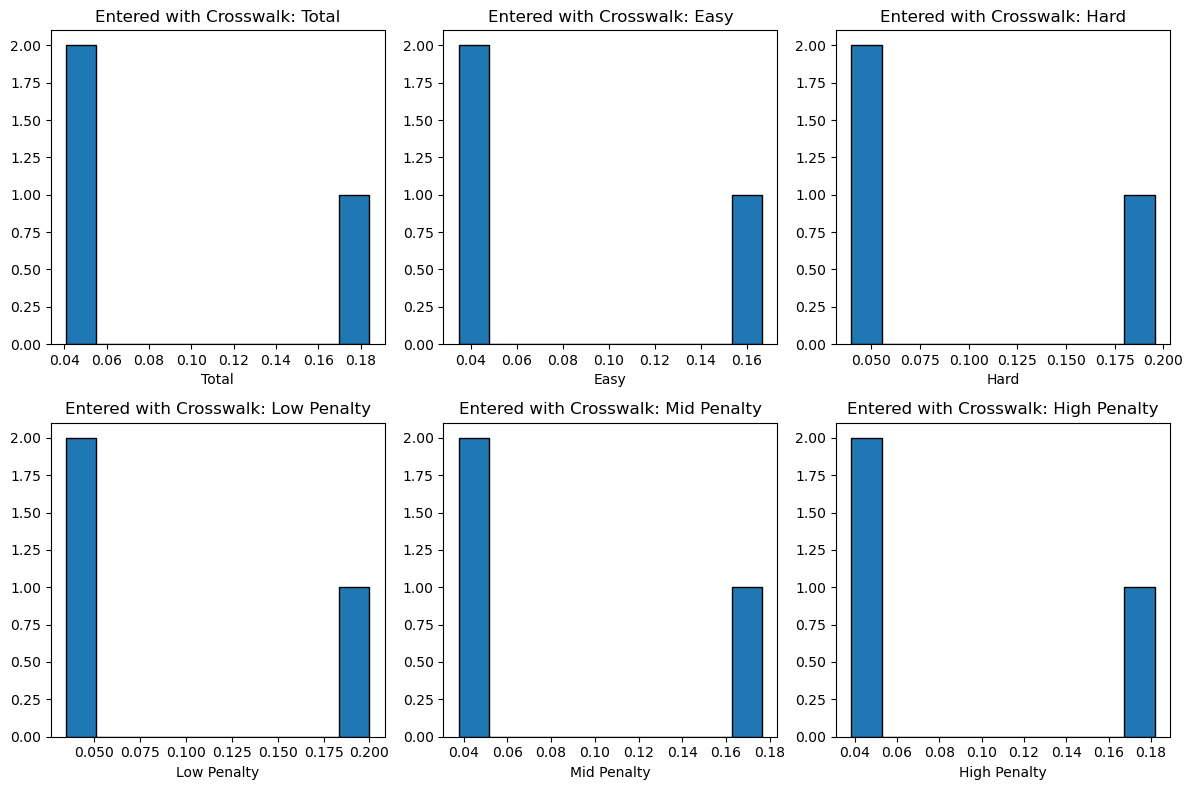

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = f"entered_road_with_crosswalk_{col_types[i]}"
    xlable = xlables[i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable=xlable, title=f"Entered with Crosswalk: {xlable}")
plt.tight_layout()
plt.show()

Total: mean = 0.18, std = 0.07 (min=0.1052631578947368 ~ max=0.2305005820721769)
Easy: mean = 0.19, std = 0.05 (min=0.1333333333333333 ~ max=0.2341772151898734)
Hard: mean = 0.18, std = 0.08 (min=0.0869565217391304 ~ max=0.2283609576427256)
Low Penalty: mean = 0.18, std = 0.07 (min=0.1 ~ max=0.2276657060518732)
Mid Penalty: mean = 0.18, std = 0.08 (min=0.088235294117647 ~ max=0.2547169811320754)
High Penalty: mean = 0.18, std = 0.04 (min=0.1363636363636363 ~ max=0.2100591715976331)


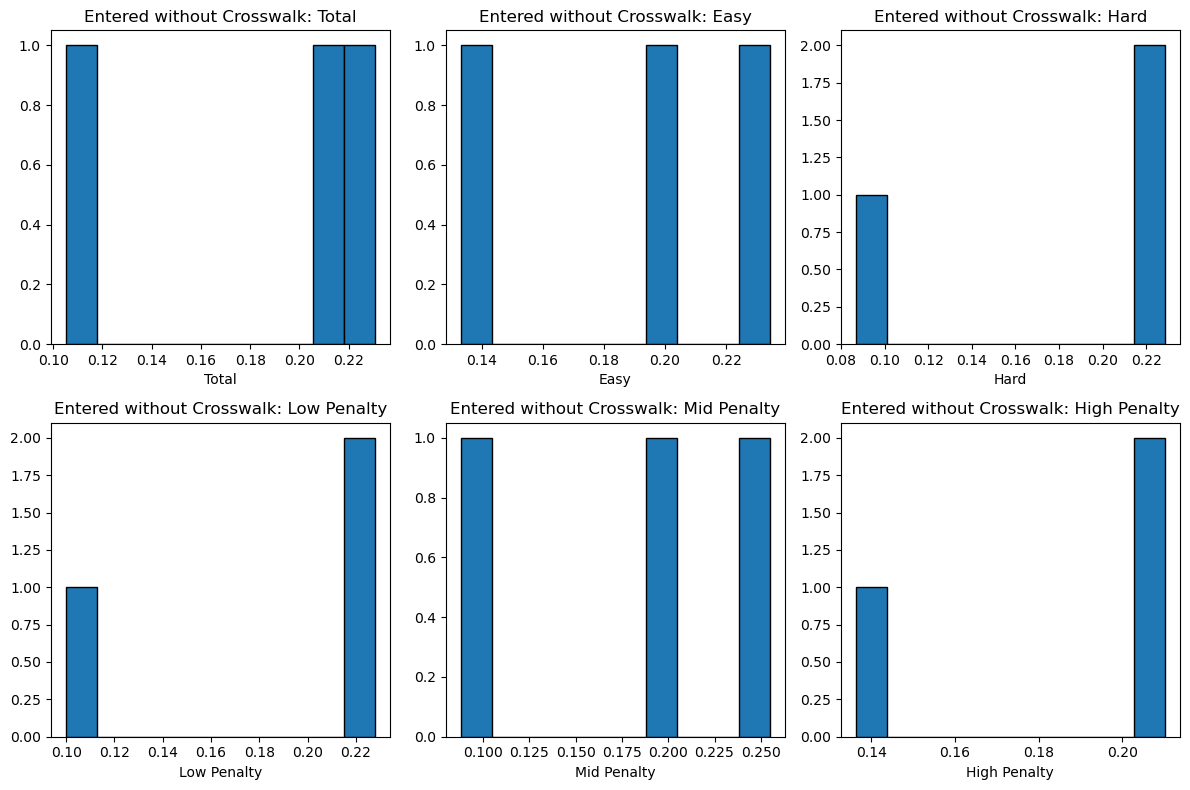

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = f"entered_road_ignoring_crosswalk_{col_types[i]}"
    xlable = xlables[i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable=xlable, title=f"Entered without Crosswalk: {xlable}")
plt.tight_layout()
plt.show()

Total: mean = 0.09, std = 0.08 (min=0.039580908032596 ~ max=0.1842105263157894)
Easy: mean = 0.08, std = 0.07 (min=0.0379746835443038 ~ max=0.1666666666666666)
Hard: mean = 0.09, std = 0.09 (min=0.0405156537753222 ~ max=0.1956521739130435)
Low Penalty: mean = 0.09, std = 0.10 (min=0.029520295202952 ~ max=0.2)
Mid Penalty: mean = 0.09, std = 0.08 (min=0.0377358490566037 ~ max=0.1764705882352941)
High Penalty: mean = 0.09, std = 0.08 (min=0.0414201183431952 ~ max=0.1818181818181818)


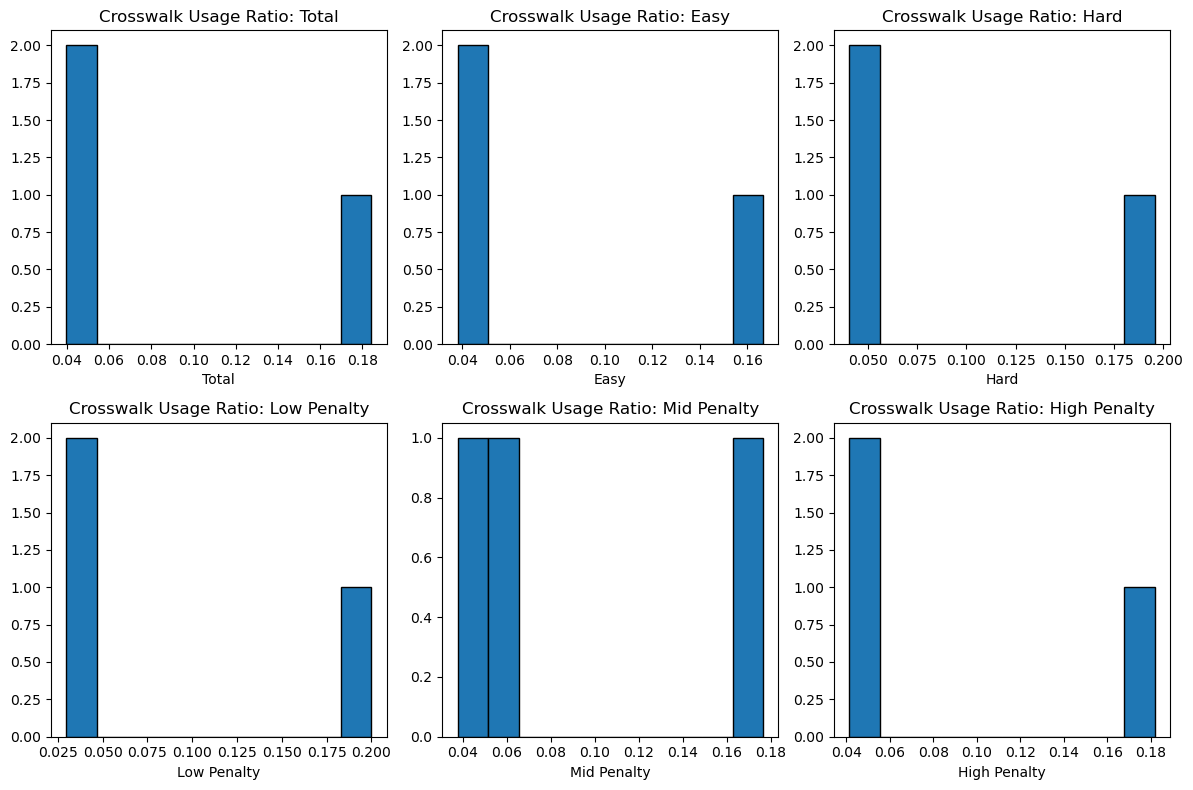

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = f"crosswalk_used_ratio_{col_types[i]}"
    xlable = xlables[i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable=xlable, title=f"Crosswalk Usage Ratio: {xlable}")
plt.tight_layout()
plt.show()

Total: mean = 0.27, std = 0.02 (min=0.2424830261881668 ~ max=0.2894736842105263)
Easy: mean = 0.27, std = 0.03 (min=0.2340425531914893 ~ max=0.3)
Hard: mean = 0.27, std = 0.02 (min=0.2473282442748091 ~ max=0.2826086956521739)
Low Penalty: mean = 0.27, std = 0.02 (min=0.2536023054755043 ~ max=0.3)
Mid Penalty: mean = 0.26, std = 0.02 (min=0.2369942196531791 ~ max=0.2861635220125786)
High Penalty: mean = 0.27, std = 0.04 (min=0.2366863905325443 ~ max=0.3181818181818182)


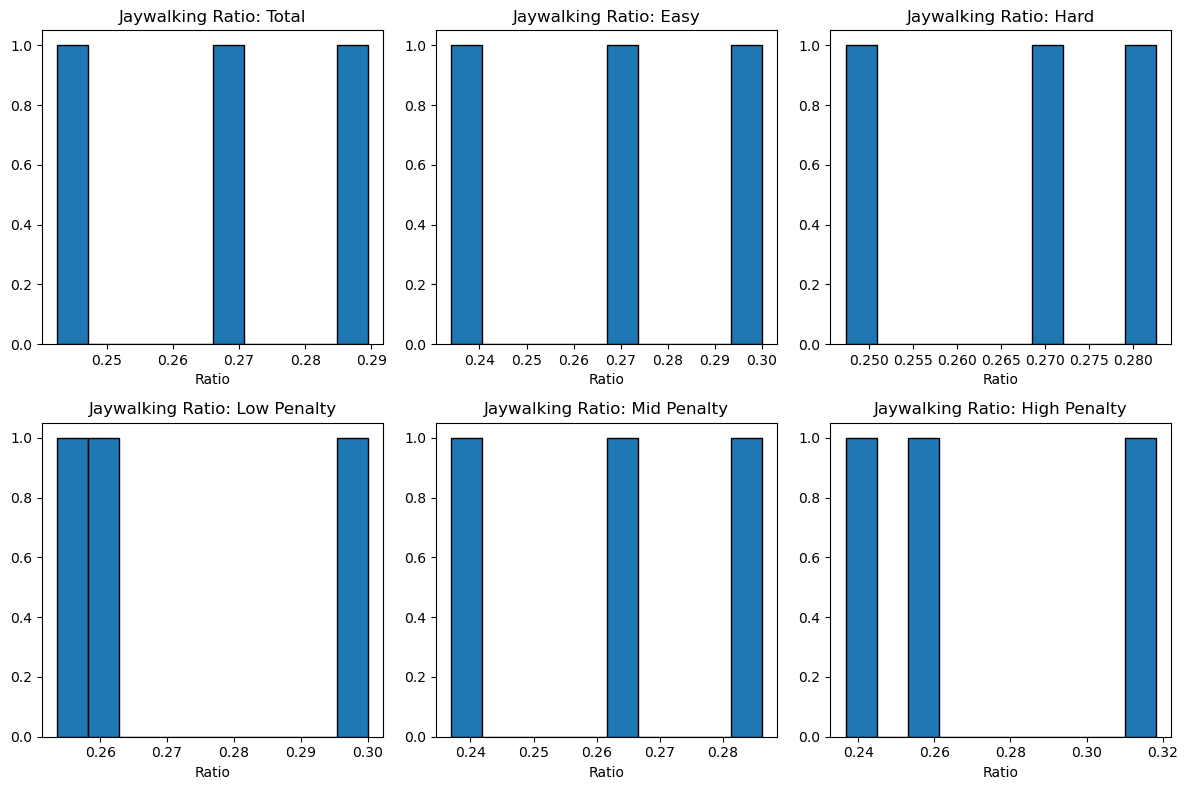

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = f"jaywalking_ratio_{col_types[i]}"
    xlable = xlables[i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable="Ratio", title=f"Jaywalking Ratio: {xlable}")
plt.tight_layout()
plt.show()

### Episode Results

Total Episodes: mean = 75.67, std = 42.15 (min=27 ~ max=100)
Bonus Scores: mean = 64.67, std = 54.28 (min=2 ~ max=97)
Timeovers: mean = 8.67, std = 14.15 (min=0 ~ max=25)
Run Overs: mean = 2.33, std = 2.08 (min=0 ~ max=4)
Bonus Score Ratio: mean = 0.66, std = 0.51 (min=0.074074074074074 ~ max=0.97)
Timeover Ratio: mean = 0.31, std = 0.53 (min=0.0 ~ max=0.925925925925926)
Run Over Ratio: mean = 0.02, std = 0.02 (min=0.0 ~ max=0.04)


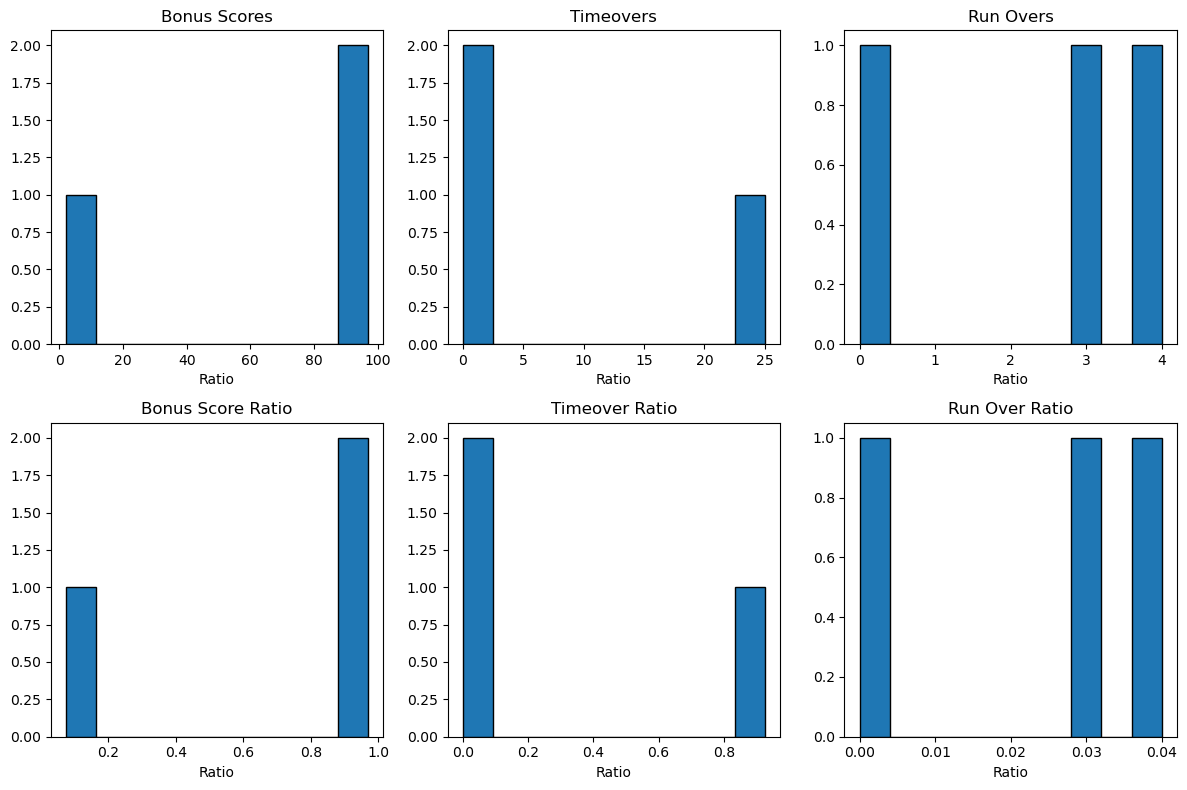

In [42]:
print_summary(df["total_episode_cnt"], "Total Episodes")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = [
        "bonus_score_episode_cnt", "timeover_episode_cnt", "run_over_episode_cnt", 
        "bonus_score_episode_ratio", "timeover_episode_ratio", "run_over_episode_ratio",
    ][i]
    xlable = ["Bonus Scores", "Timeovers", "Run Overs","Bonus Score Ratio", "Timeover Ratio", "Run Over Ratio"][i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable="Ratio", title=xlable)
plt.tight_layout()
plt.show()

Low Penalty: mean = 1.33, std = 1.53 (min=0 ~ max=3)
Mid Penalty: mean = 0.67, std = 1.15 (min=0 ~ max=2)
High Penalty: mean = 0.33, std = 0.58 (min=0 ~ max=1)
Low Penalty to Run Over Ratio: mean = 0.42, std = 0.52 (min=0.0 ~ max=1.0)
Mid Penalty to Run Over Ratio: mean = 0.17, std = 0.29 (min=0.0 ~ max=0.5)
High Penalty to Run Over Ratio: mean = 0.08, std = 0.14 (min=0.0 ~ max=0.25)
Low Penalty to Total Ratio: mean = 0.01, std = 0.02 (min=0.0 ~ max=0.03)
Mid Penalty to Total Ratio: mean = 0.01, std = 0.01 (min=0.0 ~ max=0.02)
High Penalty to Total Ratio: mean = 0.00, std = 0.01 (min=0.0 ~ max=0.01)


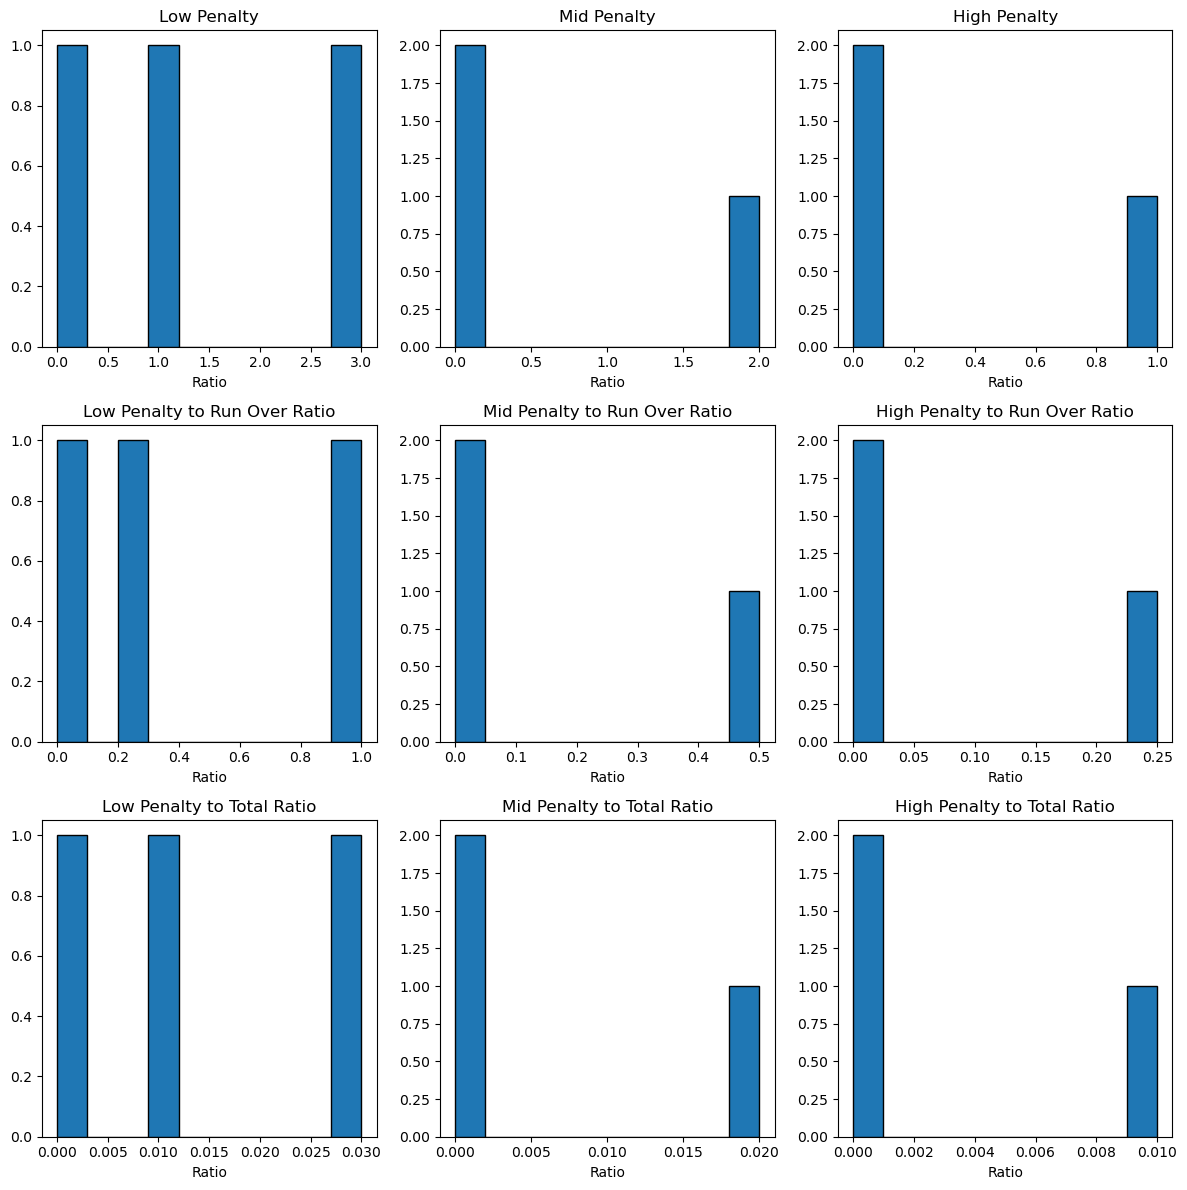

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(9):
    col = [
        "low_penalty_cnt", "mid_penalty_cnt", "high_penalty_cnt", 
        "low_penalty_ratio", "mid_penalty_ratio", "high_penalty_ratio",
        "low_penalty_full_ratio", "mid_penalty_full_ratio", "high_penalty_full_ratio",
    ][i]
    xlable = [
        "Low Penalty", "Mid Penalty", "High Penalty",
        "Low Penalty to Run Over Ratio", "Mid Penalty to Run Over Ratio", "High Penalty to Run Over Ratio",
        "Low Penalty to Total Ratio", "Mid Penalty to Total Ratio", "High Penalty to Total Ratio",
    ][i]
    print_summary(df[col], xlable)
    plot_summary(axes[i // 3, i % 3], df[col], xlable="Ratio", title=xlable)
plt.tight_layout()
plt.show()

### Locomotor Analysis

#### Action Proportions

Nothing: mean = 154.00, std = 216.53 (min=26 ~ max=404)
UP: mean = 1534.33, std = 1226.10 (min=138 ~ max=2435)
DOWN: mean = 39.67, std = 36.23 (min=0 ~ max=71)
RIGHT: mean = 494.67, std = 151.19 (min=348 ~ max=650)
LEFT: mean = 611.00, std = 43.58 (min=569 ~ max=656)
         group sum  proportion
Nothing        462    0.054347
UP            4603    0.541466
DOWN           119    0.013998
RIGHT         1484    0.174568
LEFT          1833    0.215622


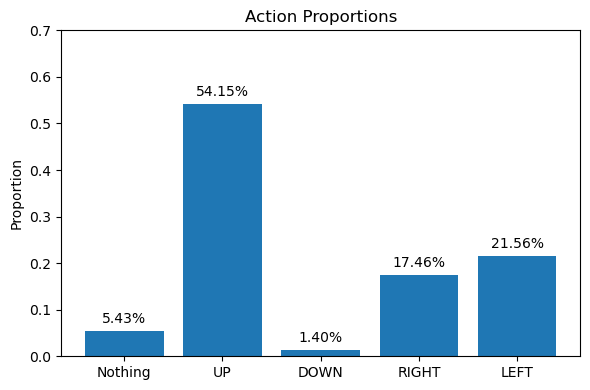

In [56]:
actions = ["Nothing", "UP", "DOWN", "RIGHT", "LEFT"]
cols = [f"action_{action}_cnt" for action in actions]
for i in range(5):
    print_summary(df[cols[i]], actions[i])

totals = df[cols].sum()
action_proportions = (totals / totals.sum())

summary = pd.DataFrame({
    "group sum": totals.values,
    "proportion": action_proportions.values
}, index=actions)
print(summary)

plt.figure(figsize=(6,4))
plt.bar(actions, action_proportions.values)
plt.ylabel("Proportion")
plt.title("Action Proportions")
plt.ylim(0, 0.7)
for i, v in enumerate(action_proportions.values):
    plt.text(i, v + 0.01, f"{v:.2%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Left/Right Movement Ratio: mean = 0.44, std = 0.23 (min=0.3012114537444933 ~ max=0.7067099567099566)


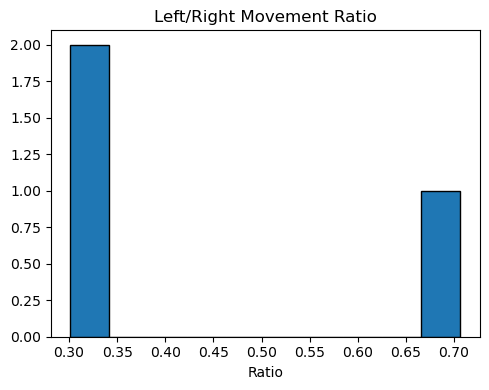

In [73]:
actions = ["Nothing", "UP", "DOWN", "RIGHT", "LEFT"]

sideway_movement_ratio = df["action_RIGHT_ratio"] + df["action_LEFT_ratio"]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
col = "sideway_movement_ratio"
xlable = "Left/Right Movement Ratio"
print_summary(sideway_movement_ratio, xlable)
plot_summary(axes, sideway_movement_ratio, xlable="Ratio", title=xlable)
plt.tight_layout()
plt.show()

#### Visited tiles

- Low Visited Unique Tile Ratio: High exploration, High crosswalk usage/search
- High Visited Unique Tile Ratio: Low exploration, Low crosswalk usage/search

Total Visited Tile Count: mean = 38.87, std = 12.64 (min=28.52 ~ max=52.96296296296296)
Total Unique Visited Tile Count: mean = 25.84, std = 7.98 (min=17.296296296296298 ~ max=33.1)
Visited Unique Tile Ratio: mean = 0.74, std = 0.36 (min=0.3265734265734266 ~ max=0.9505610098176718)


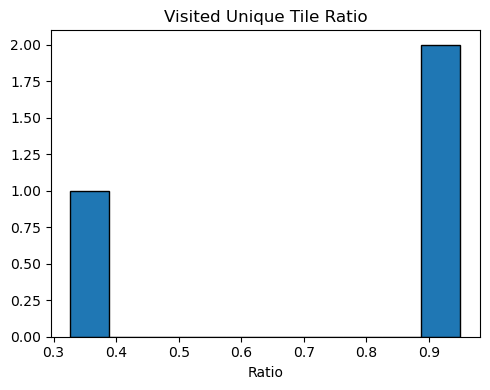

In [75]:
print_summary(df["visited_tile_cnt_mean"], "Total Visited Tile Count")
print_summary(df["visited_unique_tile_cnt_mean"], "Total Unique Visited Tile Count")

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
visited_unique_tile_ratio = df["visited_unique_tile_ratio"]
xlable = "Visited Unique Tile Ratio"
print_summary(visited_unique_tile_ratio, xlable)
plot_summary(axes, visited_unique_tile_ratio, xlable="Ratio", title=xlable)
plt.tight_layout()
plt.show()